In [2]:
from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ============================================================
# Portable project-root detection
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent

elif (CURRENT_DIR / "notebooks").exists():
    PROJECT_DIR = CURRENT_DIR

else:
    PROJECT_DIR = None

    for parent in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (parent / "notebooks").exists() and (parent / "requirements.txt").exists():
            PROJECT_DIR = parent
            break

    if PROJECT_DIR is None:
        raise FileNotFoundError(
            "Project root could not be detected. "
            "Please start JupyterLab from the CyberXAI-CSE-IDS2018 project folder."
        )

TRAIN_DIR = PROJECT_DIR / "data" / "splits" / "train"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"

for directory in [
    INTERIM_DIR,
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

train_files = sorted(TRAIN_DIR.glob("*_train.parquet"))

if not train_files:
    raise FileNotFoundError(
        f"No training files were found in:\n{TRAIN_DIR}"
    )

feature_sets_path = (
    DOCUMENTATION_DIR / "candidate_feature_sets.json"
)

if not feature_sets_path.exists():
    raise FileNotFoundError(
        f"Feature-set file not found:\n{feature_sets_path}"
    )

with open(
    feature_sets_path,
    "r",
    encoding="utf-8"
) as feature_file:
    saved_feature_sets = json.load(feature_file)

feature_sets = {
    "top_10": saved_feature_sets["top_10"],
    "top_15": saved_feature_sets["top_15"],
    "top_20": saved_feature_sets["top_20"]
}

all_candidate_features = sorted(
    set(
        feature
        for feature_list in feature_sets.values()
        for feature in feature_list
    )
)

print("Project directory:", PROJECT_DIR)
print("Training data directory:", TRAIN_DIR)
print("Training files found:", len(train_files))
print("Candidate features in union:", len(all_candidate_features))

for set_name, features in feature_sets.items():
    print(f"\n{set_name}: {len(features)} features")
    for feature in features:
        print("-", feature)
        


Project directory: D:\Sami Data Set\CyberXAI-CSE-IDS2018
Training data directory: D:\Sami Data Set\CyberXAI-CSE-IDS2018\data\splits\train
Training files found: 10
Candidate features in union: 20

top_10: 10 features
- Fwd Packet Length Max
- Init Bwd Win Bytes
- Fwd Packet Length Std
- Avg Fwd Segment Size
- Init Fwd Win Bytes
- Fwd Seg Size Min
- Flow Duration
- Flow IAT Max
- Packet Length Variance
- Subflow Fwd Bytes

top_15: 15 features
- Fwd Packet Length Max
- Init Bwd Win Bytes
- Fwd Packet Length Std
- Avg Fwd Segment Size
- Init Fwd Win Bytes
- Fwd Seg Size Min
- Flow Duration
- Flow IAT Max
- Packet Length Variance
- Subflow Fwd Bytes
- Flow IAT Mean
- Packet Length Mean
- Packet Length Max
- Avg Bwd Segment Size
- Fwd IAT Std

top_20: 20 features
- Fwd Packet Length Max
- Init Bwd Win Bytes
- Fwd Packet Length Std
- Avg Fwd Segment Size
- Init Fwd Win Bytes
- Fwd Seg Size Min
- Flow Duration
- Flow IAT Max
- Packet Length Variance
- Subflow Fwd Bytes
- Flow IAT Mean
- Packet

In [5]:
training_schema = pq.ParquetFile(
    train_files[0]
).schema.names

missing_feature_records = []

for set_name, features in feature_sets.items():
    for feature in features:
        if feature not in training_schema:
            missing_feature_records.append({
                "feature_set": set_name,
                "missing_feature": feature
            })

missing_features = pd.DataFrame(
    missing_feature_records,
    columns=["feature_set", "missing_feature"]
)

if missing_features.empty:
    print("All candidate features exist in the training data.")
else:
    display(missing_features)
    raise KeyError(
        "One or more selected features are missing."
    )

All candidate features exist in the training data.


In [8]:
TARGET_SAMPLE_ROWS = 500_000
RANDOM_SEED = 42

file_information = []

for file_path in train_files:
    row_count = pq.ParquetFile(
        file_path
    ).metadata.num_rows

    file_information.append({
        "file_path": file_path,
        "file_name": file_path.name,
        "rows": row_count
    })

file_information_df = pd.DataFrame(file_information)

total_training_rows = int(
    file_information_df["rows"].sum()
)

file_information_df["sample_rows"] = (
    file_information_df["rows"]
    / total_training_rows
    * TARGET_SAMPLE_ROWS
).round().astype(int)

display(
    file_information_df[
        ["file_name", "rows", "sample_rows"]
    ]
)

print(
    "Planned sample size:",
    f"{file_information_df['sample_rows'].sum():,}"
)



,file_name,rows,sample_rows
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,617270,57931
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,495477,46501
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,763877,71690
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,449117,42150
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,635849,59675
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,473498,44438
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,365498,34302
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,199336,18708
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,664179,62333
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,663524,62272


Planned sample size: 500,000


In [12]:
TARGET_SAMPLE_ROWS = 500_000
RANDOM_SEED = 42

file_information = []

for file_path in train_files:
    row_count = pq.ParquetFile(
        file_path
    ).metadata.num_rows

    file_information.append({
        "file_path": file_path,
        "file_name": file_path.name,
        "rows": row_count
    })

file_information_df = pd.DataFrame(file_information)

total_training_rows = int(
    file_information_df["rows"].sum()
)

file_information_df["sample_rows"] = (
    file_information_df["rows"]
    / total_training_rows
    * TARGET_SAMPLE_ROWS
).round().astype(int)

display(
    file_information_df[
        ["file_name", "rows", "sample_rows"]
    ]
)

print(
    "Planned sample size:",
    f"{file_information_df['sample_rows'].sum():,}"
)


,file_name,rows,sample_rows
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,617270,57931
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,495477,46501
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,763877,71690
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,449117,42150
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,635849,59675
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,473498,44438
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,365498,34302
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,199336,18708
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,664179,62333
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,663524,62272


Planned sample size: 500,000


In [13]:
sample_parts = []

required_columns = (
    all_candidate_features
    + [
        "binary_label",
        "source_file_id",
        "source_row_id"
    ]
)

for file_number, row in file_information_df.iterrows():
    file_path = row["file_path"]
    sample_size = int(row["sample_rows"])

    print(
        f"[{file_number + 1}/{len(file_information_df)}] "
        f"Sampling {file_path.name}",
        flush=True
    )

    df = pd.read_parquet(
        file_path,
        columns=required_columns
    )

    sample_size = min(sample_size, len(df))

    sampled_df = df.sample(
        n=sample_size,
        random_state=RANDOM_SEED + file_number
    )

    sample_parts.append(sampled_df)

    del df
    gc.collect()

validation_sample = pd.concat(
    sample_parts,
    ignore_index=True
)

validation_sample_path = (
    INTERIM_DIR
    / "candidate_feature_validation_sample.parquet"
)

validation_sample.to_parquet(
    validation_sample_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)

print(
    "\nValidation sample records:",
    f"{len(validation_sample):,}"
)

class_distribution = (
    validation_sample["binary_label"]
    .value_counts()
    .sort_index()
    .rename_axis("binary_label")
    .reset_index(name="count")
)

class_distribution["traffic_type"] = (
    class_distribution["binary_label"]
    .map({
        0: "Benign",
        1: "Malicious"
    })
)

class_distribution["percentage"] = (
    class_distribution["count"]
    / class_distribution["count"].sum()
    * 100
).round(4)

display(class_distribution)

[1/10] Sampling Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_train.parquet
[2/10] Sampling Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_train.parquet
[3/10] Sampling DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_train.parquet
[4/10] Sampling DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_train.parquet
[5/10] Sampling DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_train.parquet
[6/10] Sampling DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_train.parquet
[7/10] Sampling Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_train.parquet
[8/10] Sampling Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter_train.parquet
[9/10] Sampling Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter_train.parquet
[10/10] Sampling Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter_train.parquet

Validation sample records: 500,000


,binary_label,count,traffic_type,percentage
0,0,400239,Benign,80.0478
1,1,99761,Malicious,19.9522


In [18]:
X = validation_sample[
    all_candidate_features
].copy()

y = validation_sample[
    "binary_label"
].astype("int8").copy()

for feature in X.columns:
    X[feature] = pd.to_numeric(
        X[feature],
        errors="raise"
    ).astype("float32")

if X.isna().any().any():
    raise ValueError(
        "Unexpected missing values were found."
    )

X_development, X_validation, y_development, y_validation = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_SEED
    )
)

print("Development records:", f"{len(X_development):,}")
print("Validation records:", f"{len(X_validation):,}")

print("\nDevelopment distribution:")
print(
    y_development.value_counts(
        normalize=True
    ).sort_index()
)

print("\nValidation distribution:")
print(
    y_validation.value_counts(
        normalize=True
    ).sort_index()
)


Development records: 400,000
Validation records: 100,000

Development distribution:
binary_label
0    0.800477
1    0.199522
Name: proportion, dtype: float64

Validation distribution:
binary_label
0    0.80048
1    0.19952
Name: proportion, dtype: float64


In [19]:
MAX_ITERATIONS = 1000

evaluation_records = []
confusion_records = []

trained_validation_models = {}

for set_name, features in feature_sets.items():
    print(
        f"\nEvaluating {set_name} "
        f"({len(features)} features)",
        flush=True
    )

    model_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                penalty="l2",
                class_weight="balanced",
                max_iter=MAX_ITERATIONS,
                tol=1e-3,
                random_state=RANDOM_SEED
            )
        )
    ])

    fit_start = time.time()

    with warnings.catch_warnings(record=True) as model_warnings:
        warnings.simplefilter("always")

        model_pipeline.fit(
            X_development[features],
            y_development
        )

    training_seconds = time.time() - fit_start

    prediction_start = time.time()

    validation_predictions = model_pipeline.predict(
        X_validation[features]
    )

    prediction_seconds = (
        time.time() - prediction_start
    )

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        validation_predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_validation,
        validation_predictions
    )

    precision = precision_score(
        y_validation,
        validation_predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_predictions,
        pos_label=1,
        zero_division=0
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    classifier = model_pipeline.named_steps[
        "classifier"
    ]

    iterations_used = int(
        np.max(classifier.n_iter_)
    )

    converged = (
        iterations_used < MAX_ITERATIONS
    )

    evaluation_records.append({
        "feature_set": set_name,
        "number_of_features": len(features),
        "accuracy": accuracy,
        "malicious_precision": precision,
        "malicious_recall": recall,
        "malicious_f1": f1,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "training_seconds": round(
            training_seconds,
            3
        ),
        "prediction_seconds": round(
            prediction_seconds,
            3
        ),
        "iterations_used": iterations_used,
        "converged": converged,
        "warning_count": len(model_warnings)
    })

    confusion_records.extend([
        {
            "feature_set": set_name,
            "actual_class": "Benign",
            "predicted_class": "Benign",
            "count": int(tn)
        },
        {
            "feature_set": set_name,
            "actual_class": "Benign",
            "predicted_class": "Malicious",
            "count": int(fp)
        },
        {
            "feature_set": set_name,
            "actual_class": "Malicious",
            "predicted_class": "Benign",
            "count": int(fn)
        },
        {
            "feature_set": set_name,
            "actual_class": "Malicious",
            "predicted_class": "Malicious",
            "count": int(tp)
        }
    ])

    trained_validation_models[set_name] = (
        model_pipeline
    )

    model_path = (
        MODELS_DIR
        / f"logistic_validation_{set_name}.joblib"
    )

    joblib.dump(
        model_pipeline,
        model_path
    )

    print(
        f"F1: {f1:.4f} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f} | "
        f"False positives: {fp:,}",
        flush=True
    )

feature_set_results = pd.DataFrame(
    evaluation_records
)

confusion_results = pd.DataFrame(
    confusion_records
)

display(feature_set_results)



Evaluating top_10 (10 features)
F1: 0.5439 | Recall: 0.7919 | Precision: 0.4142 | False positives: 22,340

Evaluating top_15 (15 features)
F1: 0.6054 | Recall: 0.9193 | Precision: 0.4513 | False positives: 22,299

Evaluating top_20 (20 features)
F1: 0.7195 | Recall: 0.9374 | Precision: 0.5838 | False positives: 13,336


,feature_set,number_of_features,accuracy,malicious_precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,training_seconds,prediction_seconds,iterations_used,converged,warning_count
0,top_10,10,0.73507,0.414248,0.791850,0.543940,0.279083,0.208150,57708,22340,4153,15799,106.525,0.260,23,True,1
1,top_15,15,0.76090,0.451304,0.919256,0.605393,0.278570,0.080744,57749,22299,1611,18341,202.489,0.099,38,True,1
2,top_20,20,0.85416,0.583770,0.937450,0.719495,0.166600,0.062550,66712,13336,1248,18704,230.890,0.038,48,True,1


In [22]:
ranked_feature_sets = (
    feature_set_results
    .sort_values(
        by=[
            "malicious_f1",
            "malicious_recall",
            "false_positive_rate",
            "number_of_features"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

ranked_feature_sets[
    "selection_rank"
] = np.arange(
    1,
    len(ranked_feature_sets) + 1
)

display(
    ranked_feature_sets[
        [
            "selection_rank",
            "feature_set",
            "number_of_features",
            "accuracy",
            "malicious_precision",
            "malicious_recall",
            "malicious_f1",
            "false_positive_rate",
            "false_negative_rate",
            "training_seconds",
            "converged"
        ]
    ]
)

selected_set_name = ranked_feature_sets.loc[
    0,
    "feature_set"
]

selected_features = feature_sets[
    selected_set_name
]

print(
    "\nRecommended feature set:",
    selected_set_name
)

print(
    "Number of selected features:",
    len(selected_features)
)

for feature in selected_features:
    print("-", feature)

,selection_rank,feature_set,number_of_features,accuracy,malicious_precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate,training_seconds,converged
0,1,top_20,20,0.85416,0.583770,0.937450,0.719495,0.166600,0.062550,230.890,True
1,2,top_15,15,0.76090,0.451304,0.919256,0.605393,0.278570,0.080744,202.489,True
2,3,top_10,10,0.73507,0.414248,0.791850,0.543940,0.279083,0.208150,106.525,True



Recommended feature set: top_20
Number of selected features: 20
- Fwd Packet Length Max
- Init Bwd Win Bytes
- Fwd Packet Length Std
- Avg Fwd Segment Size
- Init Fwd Win Bytes
- Fwd Seg Size Min
- Flow Duration
- Flow IAT Max
- Packet Length Variance
- Subflow Fwd Bytes
- Flow IAT Mean
- Packet Length Mean
- Packet Length Max
- Avg Bwd Segment Size
- Fwd IAT Std
- Bwd Packet Length Std
- Bwd Packet Length Max
- Bwd Packets Length Total
- Bwd IAT Min
- RST Flag Count


In [26]:
feature_set_results.to_csv(
    TABLES_DIR
    / "candidate_feature_set_validation_results.csv",
    index=False
)

ranked_feature_sets.to_csv(
    TABLES_DIR
    / "candidate_feature_set_ranking.csv",
    index=False
)

confusion_results.to_csv(
    TABLES_DIR
    / "candidate_feature_set_confusion_results.csv",
    index=False
)

selected_feature_information = {
    "selected_feature_set": selected_set_name,
    "number_of_features": len(selected_features),
    "features": selected_features,
    "selection_method": (
        "Highest malicious-class F1-score, followed "
        "by recall, false-positive rate and feature count"
    ),
    "validation_source": (
        "Training-data-only validation sample"
    ),
    "final_test_set_used": False,
    "random_seed": RANDOM_SEED
}

with open(
    DOCUMENTATION_DIR
    / "selected_feature_set.json",
    "w",
    encoding="utf-8"
) as selected_file:
    json.dump(
        selected_feature_information,
        selected_file,
        indent=4
    )

print("Validation results saved successfully.")


Validation results saved successfully.


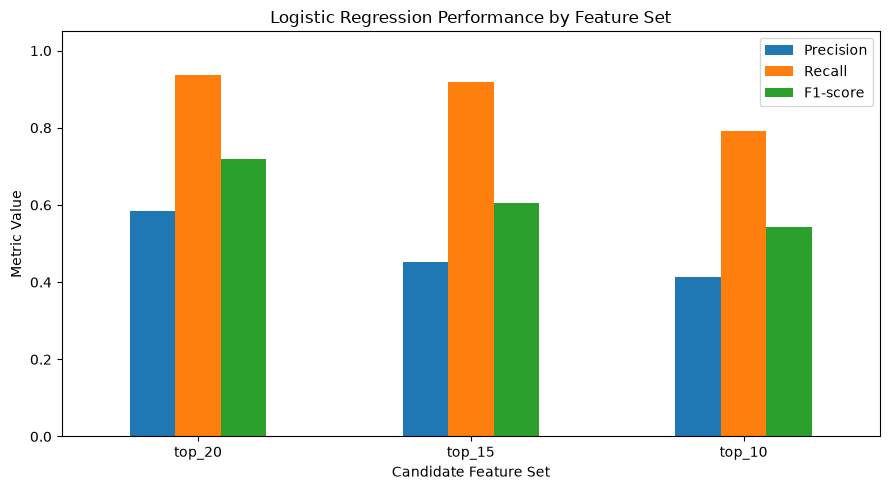

Comparison figure saved to: D:\Sami Data Set\outputs\figures\candidate_feature_set_comparison.png


In [31]:
plot_data = ranked_feature_sets.set_index(
    "feature_set"
)[
    [
        "malicious_precision",
        "malicious_recall",
        "malicious_f1"
    ]
]

plt.figure(figsize=(9, 5))

plot_data.plot(
    kind="bar",
    ax=plt.gca()
)

plt.title(
    "Logistic Regression Performance by Feature Set"
)
plt.xlabel("Candidate Feature Set")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(
    ["Precision", "Recall", "F1-score"]
)

plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR
    / "candidate_feature_set_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Comparison figure saved to:",
    comparison_figure_path
)



In [32]:
selected_pipeline = trained_validation_models[
    selected_set_name
]

selected_classifier = (
    selected_pipeline.named_steps["classifier"]
)

coefficient_table = pd.DataFrame({
    "feature": selected_features,
    "coefficient":
        selected_classifier.coef_[0]
})

coefficient_table[
    "absolute_coefficient"
] = coefficient_table[
    "coefficient"
].abs()

coefficient_table = coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coefficient_table)

coefficient_table.to_csv(
    TABLES_DIR
    / "selected_feature_set_logistic_coefficients.csv",
    index=False
)

,feature,coefficient,absolute_coefficient
19,RST Flag Count,1.624881,1.624881
1,Init Bwd Win Bytes,-1.585945,1.585945
5,Fwd Seg Size Min,1.424398,1.424398
16,Bwd Packet Length Max,1.002182,1.002182
2,Fwd Packet Length Std,-1.001220,1.001220
6,Flow Duration,-0.677837,0.677837
0,Fwd Packet Length Max,-0.547241,0.547241
13,Avg Bwd Segment Size,-0.499279,0.499279
12,Packet Length Max,-0.383852,0.383852
8,Packet Length Variance,-0.337965,0.337965


## Candidate Feature-Set Validation Conclusion

The top-10, top-15 and top-20 candidate feature sets were compared
using the same Logistic Regression configuration and the same
training-only development and validation partitions. The frozen final
test set was not accessed.

Feature-set selection was based primarily on malicious-class
F1-score, followed by malicious recall, false-positive rate and the
number of retained features. This prevented the feature subset from
being selected through accuracy alone.

The recommended feature set will now be frozen and used consistently
for the comparative development of Logistic Regression, Decision
Tree, Random Forest and XGBoost models. Selection at this stage remains
based on training and validation evidence; final performance will only
be reported after evaluation on the untouched test set.

In [33]:
from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is unavailable and will be excluded.")

# ============================================================
# Portable project-root detection
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent

elif (CURRENT_DIR / "notebooks").exists():
    PROJECT_DIR = CURRENT_DIR

else:
    PROJECT_DIR = None

    for parent in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (parent / "notebooks").exists() and (parent / "requirements.txt").exists():
            PROJECT_DIR = parent
            break

    if PROJECT_DIR is None:
        raise FileNotFoundError(
            "Project root could not be detected. "
            "Please start JupyterLab from the CyberXAI-CSE-IDS2018 project folder."
        )

INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"
PREDICTIONS_DIR = PROJECT_DIR / "outputs" / "predictions"

for directory in [
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

sample_path = (
    INTERIM_DIR
    / "candidate_feature_validation_sample.parquet"
)

selected_features_path = (
    DOCUMENTATION_DIR / "selected_feature_set.json"
)

if not sample_path.exists():
    raise FileNotFoundError(
        f"Validation sample not found:\n{sample_path}"
    )

if not selected_features_path.exists():
    raise FileNotFoundError(
        f"Selected feature file not found:\n"
        f"{selected_features_path}"
    )

print("Setup completed.")

Setup completed.


In [35]:
with open(
    selected_features_path,
    "r",
    encoding="utf-8"
) as feature_file:
    selected_feature_information = json.load(feature_file)

selected_set_name = selected_feature_information[
    "selected_feature_set"
]

selected_features = selected_feature_information[
    "features"
]

print("Selected feature set:", selected_set_name)
print("Number of features:", len(selected_features))

for number, feature in enumerate(
    selected_features,
    start=1
):
    print(f"{number:02d}. {feature}")

Selected feature set: top_20
Number of features: 20
01. Fwd Packet Length Max
02. Init Bwd Win Bytes
03. Fwd Packet Length Std
04. Avg Fwd Segment Size
05. Init Fwd Win Bytes
06. Fwd Seg Size Min
07. Flow Duration
08. Flow IAT Max
09. Packet Length Variance
10. Subflow Fwd Bytes
11. Flow IAT Mean
12. Packet Length Mean
13. Packet Length Max
14. Avg Bwd Segment Size
15. Fwd IAT Std
16. Bwd Packet Length Std
17. Bwd Packet Length Max
18. Bwd Packets Length Total
19. Bwd IAT Min
20. RST Flag Count
